# Aula 7 - Tracking Data e xG com Posicionamento de Jogadores

## Conteúdo programático
- Engenharia de atributos com *tracking data* (dados de rastreamento) para modelar finalizações.
- Rede neural rasa para probabilidade de gol.
- Avaliação com curva ROC, calibração e *Brier score*.
- Aplicação do modelo em competição diferente para comparação de jogadores.

## Objetivos da aula
- Incorporar contexto defensivo e do goleiro ao modelo de finalização.
- Avaliar robustez do modelo fora da base de treinamento.


In [ ]:
from pathlib import Path
import os


def _find_repo_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        nested_lessons = candidate / "Curso - Analise de dados Futebol" / "course" / "lessons"
        plain_lessons = candidate / "course" / "lessons"
        if nested_lessons.exists() or plain_lessons.exists():
            return candidate
    return current


REPO_ROOT = _find_repo_root()
LESSONS_BASE = REPO_ROOT / "Curso - Analise de dados Futebol" / "course" / "lessons"
if not LESSONS_BASE.exists():
    LESSONS_BASE = REPO_ROOT / "course" / "lessons"

AULA_DIR = LESSONS_BASE / "aula7-posicionamento-e-movimento"
if AULA_DIR.exists():
    os.chdir(AULA_DIR)
else:
    print(f"Aviso: diretório da aula não encontrado: {AULA_DIR}")

print("Diretório de trabalho definido para:", Path.cwd())


Diretório de trabalho definido para: /home/rafael/Downloads/Soccermatics-main/Curso - Analise de dados Futebol/course/lessons/aula7-posicionamento-e-movimento


## Bloco 1 - `plot_xG_tracking`

Construímos modelo de xG com dados de rastreamento para incorporar contexto posicional.

Fonte incorporada: `SoccerMatics - plot_xG_tracking.ipynb`


In [2]:
%matplotlib inline


# Expected Goals (Gols Esperados) Incluindo Posições dos Jogadores

Nesta aula, vamos passo a passo pelo processo de criação de um modelo de Expected Goals (gols esperados) com informações adicionais sobre a localização dos jogadores adversários. Este tutorial segue escolhas de design semelhantes ao modelo de Expected Goals (gols esperados) de Javier Fernandez em  [Um framework para a avaliação detalhada do valor instantâneo esperado de posses de bola no futebol](https://link.springer.com/artigo/10.1007/s10994-021-05989-6).

Vamos treinar uma rede neural rasa com as seguintes variáveis (features):

- Localização da bola (x)
- Variável binária indicando se a bola está mais próxima do gol do que o goleiro adversário
- ângulo entre bola e gol
- distância entre bola e gol
- distância entre bola e o goleiro
- distância entre bola e o goleiro no eixo y
- Número de jogadores adversários dentro do triângulo formado entre a localização da bola e os postes do gol adversário
- Número de jogadores adversários a menos de 3 metros da localização da bola
- Variável binária indicando se o chute foi um cabeceio
- Expected Goals (gols esperados) baseados na distância para o gol e no ângulo entre a bola e o gol

In [3]:
#importing necessary libraries
from mplsoccer import Sbopen
import pandas as pd
import numpy as np
import warnings 
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import os
import random as rn
import tensorflow as tf
#warnings not visible on the course webpage
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

#setting random seeds so that the results are reproducible on the webpage
os.environ['PYTHONHASHSEED'] = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = ''
np.random.seed(1)
rn.seed(1)
tf.random.set_seed(1)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

2026-02-23 22:47:31.278411: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 22:47:31.754524: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 22:47:33.653064: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Abrindo os Dados

Para esta tarefa, usaremos os dados da Indian Super League 2021/2022 da Statsbomb, pois esse é o único conjunto de dados publicamente disponível que contém tanto eventos quanto tracking data (dados de rastreamento) para a temporada inteira. Vamos abrir os dados de cada jogo e armazená-los em dataframes chamados shot_df e track_df. Além disso, converteremos as distâncias de jardas para metros. Por fim, vamos filtrar os chutes onde a bola estava rolando e remover os chutes sem goleiros rastreados.

In [4]:
parser = Sbopen()
#get list of games during Indian Super League season
df_match = parser.match(competition_id=1238, season_id=108)

matches = df_match.match_id.unique()

shot_df = pd.DataFrame()
track_df = pd.DataFrame()
#store data in one dataframe
for match in matches:
    #open events
    df_event = parser.event(match)[0]
    #open 360 data
    df_track = parser.event(match)[2]
    #get shots
    shots = df_event.loc[df_event["type_name"] == "Shot"]
    shots.x = shots.x.apply(lambda cell: cell*105/120)
    shots.y = shots.y.apply(lambda cell: cell*68/80)
    df_track.x = df_track.x.apply(lambda cell: cell*105/120)
    df_track.y = df_track.y.apply(lambda cell: cell*68/80)
    #append event and trackings to a dataframe
    shot_df = pd.concat([shot_df, shots], ignore_index = True)
    track_df = pd.concat([track_df, df_track], ignore_index = True)

#reset indicies    
shot_df.reset_index(drop=True, inplace=True)    
track_df.reset_index(drop=True, inplace=True)  
#filter out non open-play shots  
shot_df = shot_df.loc[shot_df["sub_type_name"] == "Open Play"]
#filter out shots where goalkeeper was not tracked
gks_tracked = track_df.loc[track_df["teammate"] == False].loc[track_df["position_name"] == "Goalkeeper"]['id'].unique()
shot_df = shot_df.loc[shot_df["id"].isin(gks_tracked)]

## Engenharia de Atributos

Nesta seção, vamos criar os atributos mencionados anteriormente. Eles serão armazenados em um dataframe chamado model_vars. Recomendamos ler os comentários do código para entender melhor essa parte do tutorial.


In [5]:
#take important variables from shot dataframe
model_vars = shot_df[["id", "index", "x", "y"]]
#get the dependent variable
model_vars["goal"] = shot_df.outcome_name.apply(lambda cell: 1 if cell == "Goal" else 0)
#change the dependent variable to object for basic xG modelling
model_vars["goal_smf"] = model_vars["goal"].astype(object)
# ball location (x)
model_vars['x0'] = model_vars.x
# x to calculate angle and distance
model_vars["x"] = model_vars.x.apply(lambda cell: 105-cell)
# c to calculate angle and distance between ball and the goal as in Lesson 2
model_vars["c"] = model_vars.y.apply(lambda cell: abs(34-cell))
#calculating angle and distance as in Lesson 2
model_vars["angle"] = np.where(np.arctan(7.32 * model_vars["x"] / (model_vars["x"]**2 + model_vars["c"]**2 - (7.32/2)**2)) >= 0, np.arctan(7.32 * model_vars["x"] /(model_vars["x"]**2 + model_vars["c"]**2 - (7.32/2)**2)), np.arctan(7.32 * model_vars["x"] /(model_vars["x"]**2 + model_vars["c"]**2 - (7.32/2)**2)) + np.pi)*180/np.pi
model_vars["distance"] = np.sqrt(model_vars["x"]**2 + model_vars["c"]**2)

#calculating basic xG using logistic regression
def params(df):
    test_model = smf.glm(formula="goal_smf ~ angle + distance", data=df,
                               family=sm.families.Binomial()).fit()
    #print summary
    return test_model.params.to_numpy()
def calculate_xG(sh, b):
   bsum=b[0]
   for i,v in enumerate(["angle", "distance"]):
       bsum=bsum+b[i+1]*sh[v]
   xG = 1/(1+np.exp(bsum))
   return xG

#expected goals based on distance to goal and angle between the ball and the goal
b = params(model_vars)
model_vars["xg_basic"]= model_vars.apply(calculate_xG, b = b, axis=1)

#ball_goalkeeper distance
def dist_to_gk(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #check goalkeeper position 
    gk_pos = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False].loc[track_df["position_name"] == "Goalkeeper"][["x", "y"]]
    #calculate distance from event to goalkeeper position
    dist = np.sqrt((test_shot["x"] - gk_pos["x"])**2 + (test_shot["y"] - gk_pos["y"])**2)
    return dist.iloc[0]
#store distance from event to goalkeeper position in a dataframe 
model_vars["gk_distance"] = shot_df.apply(dist_to_gk, track_df = track_df, axis = 1)


#ball goalkeeper y axis
def y_to_gk(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #calculate distance from event to goalkeeper position
    gk_pos = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False].loc[track_df["position_name"] == "Goalkeeper"][["y"]]
    #calculate distance from event to goalkeeper position in y axis
    dist = abs(test_shot["y"] - gk_pos["y"])
    return dist.iloc[0]

#store distance in y axis from event to goalkeeper position in a dataframe 
model_vars["gk_distance_y"] = shot_df.apply(y_to_gk, track_df = track_df, axis = 1)

#number of players less than 3 meters away from the ball
def three_meters_away(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #get all opposition's player location
    player_position = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False][["x", "y"]]
    #calculate their distance to the ball
    dist = np.sqrt((test_shot["x"] - player_position["x"])**2 + (test_shot["y"] - player_position["y"])**2)
    #return how many are closer to the ball than 3 meters
    return len(dist[dist<3])
#store number of opposition's players closer than 3 meters in a dataframe 
model_vars["close_players"] = shot_df.apply(three_meters_away, track_df = track_df, axis = 1)

#number of players inside a triangle
def players_in_triangle(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #get all opposition's player location
    player_position = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False][["x", "y"]]
    #checking if point inside a triangle 
    x1 = 105
    y1 = 34 - 7.32/2
    x2 = 105
    y2 = 34 + 7.32/2
    x3 = test_shot["x"]
    y3 = test_shot["y"]
    xp = player_position["x"]
    yp = player_position["y"]
    c1 = (x2-x1)*(yp-y1)-(y2-y1)*(xp-x1)
    c2 = (x3-x2)*(yp-y2)-(y3-y2)*(xp-x2)
    c3 = (x1-x3)*(yp-y3)-(y1-y3)*(xp-x3)
    #get number of players inside a triangle 
    return len(player_position.loc[((c1<0) & (c2<0) & (c3<0)) | ((c1>0) & (c2>0) & (c3>0))])

#store number of opposition's players inside a triangle in a dataframe 
model_vars["triangle"] = shot_df.apply(players_in_triangle, track_df = track_df, axis = 1)

#goalkeeper distance to goal
def gk_dist_to_goal(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #get goalkeeper position
    gk_pos = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False].loc[track_df["position_name"] == "Goalkeeper"][["x", "y"]]
    #calculate their distance to goal
    dist = np.sqrt((105 -gk_pos["x"])**2 + (34 - gk_pos["y"])**2)
    return dist.iloc[0]
    
#store opposition's goalkeeper distance to goal in a dataframe 
model_vars["gk_dist_to_goal"] = shot_df.apply(gk_dist_to_goal, track_df = track_df, axis = 1)
#create binary varibale 1 if ball is closer to the goal than goalkeeper
model_vars["is_closer"] = np.where(model_vars["gk_dist_to_goal"] > model_vars["distance"], 1, 0)
#create binary variable 1 if header
model_vars["header"] = shot_df.body_part_name.apply(lambda cell: 1 if cell == "Head" else 0)


#store dependent variable in a numpy array
y = model_vars["goal"].values
#store independent variables in a numpy array
X = model_vars[["x0", "is_closer", "angle", "distance", "gk_distance", "gk_distance_y", "triangle", "close_players", "header", "xg_basic"]].values


## Treinando a Rede Neural

Com os atributos criados, podemos agora treinar a rede neural. Vamos dividir os dados em 60% para treinamento, 20% para validação e 20% para teste. Em seguida, faremos o escalonamento dos dados de entrada. O próximo passo é criar o modelo de rede neural. Isso segue escolhas de design semelhantes ao modelo de Javier Fernandez: duas camadas densas com 10 neurônios, seguidas de uma ativação ReLU, e uma camada final com 1 neurônio e ativação sigmoid para calcular a probabilidade. O modelo é otimizado com a pontuação Brier usando o otimizador Adam, com taxa de aprendizado de 0.001 e betas padrão. Também usamos early stopping sugerido, com delta mínimo de 1e-5 e tamanho do lote (batch size) igual a 16. No entanto, a paciência é configurada para 50 para evitar a parada prematura quando a perda de validação não está mudando.


Epoch 1/1000


2026-02-23 22:53:02.033955: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8794 - loss: 0.1639 - val_accuracy: 0.8974 - val_loss: 0.1098
Epoch 2/1000
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8974 - loss: 0.1020 - val_accuracy: 0.8974 - val_loss: 0.0929
Epoch 3/1000
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8974 - loss: 0.0940 - val_accuracy: 0.8974 - val_loss: 0.0895
Epoch 4/1000
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8974 - loss: 0.0919 - val_accuracy: 0.8974 - val_loss: 0.0870
Epoch 5/1000
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8974 - loss: 0.0901 - val_accuracy: 0.8974 - val_loss: 0.0844
Epoch 6/1000
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8974 - loss: 0.0883 - val_accuracy: 0.8974 - val_loss: 0.0817
Epoch 7/1000
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8974 - loss: 0.0866 - val_accuracy: 0.9009 - val_loss: 0.0796
Epoch 8/1000
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8986 - loss: 0.0852 - val_accuracy:

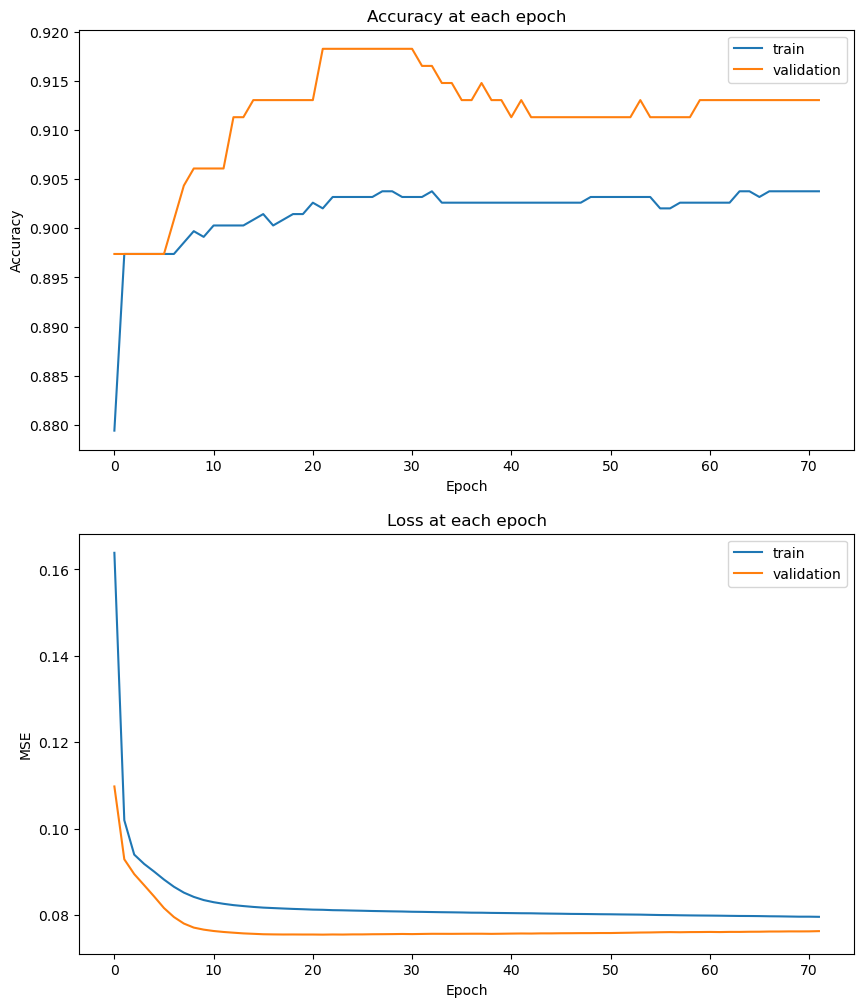

In [6]:
#import machine learning libraries 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


#spllit the data to train, validation and test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.6, random_state = 123, stratify = y)
X_cal, X_val, y_cal, y_val  = train_test_split(X_test, y_test, train_size = 0.5, random_state = 123, stratify = y_test)
#scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_cal = scaler.transform(X_cal)

#creating a function with a model architecture
def create_model():
    model = Sequential([
        Dense(10, activation='relu'),
        Dense(10, activation='relu'),
        Dense(1, activation = 'sigmoid'),
    ])
    opt = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
    model.compile(optimizer=opt, loss="mean_squared_error" , metrics=['accuracy'])
    return model

#create model
model = create_model()
#create an early stopping object
callback = EarlyStopping(min_delta=1e-5, patience = 50, mode = "min", monitor = "val_loss", restore_best_weights=True)
#fit the model 
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=1000, verbose=1, batch_size=16, callbacks = [callback])    

fig, axs = plt.subplots(2, figsize=(10,12))
#plot training history - accuracy
axs[0].plot(history.history['accuracy'], label='train')   
axs[0].plot(history.history['val_accuracy'], label='validation')
axs[0].set_title("Accuracy at each epoch")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")
axs[0].legend()

#plot training history - loss function
axs[1].plot(history.history['loss'], label='train')   
axs[1].plot(history.history['val_loss'], label='validation')
axs[1].legend()
axs[1].set_title("Loss at each epoch")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("MSE")
plt.show()

## Avaliando Nosso Modelo

Para avaliar nosso modelo, vamos calcular a curva ROC AUC e investigar as curvas de calibração. Nos gráficos, podemos observar que algumas das probabilidades mais altas são subestimadas pelo nosso modelo, mas os resultados são satisfatórios, dado o número de dados que temos e a rede neural rasa. Também vamos calcular o Brier score nos dados não vistos (dados de teste). O Brier score obtido foi 0.08, o que é considerado um bom valor. 


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


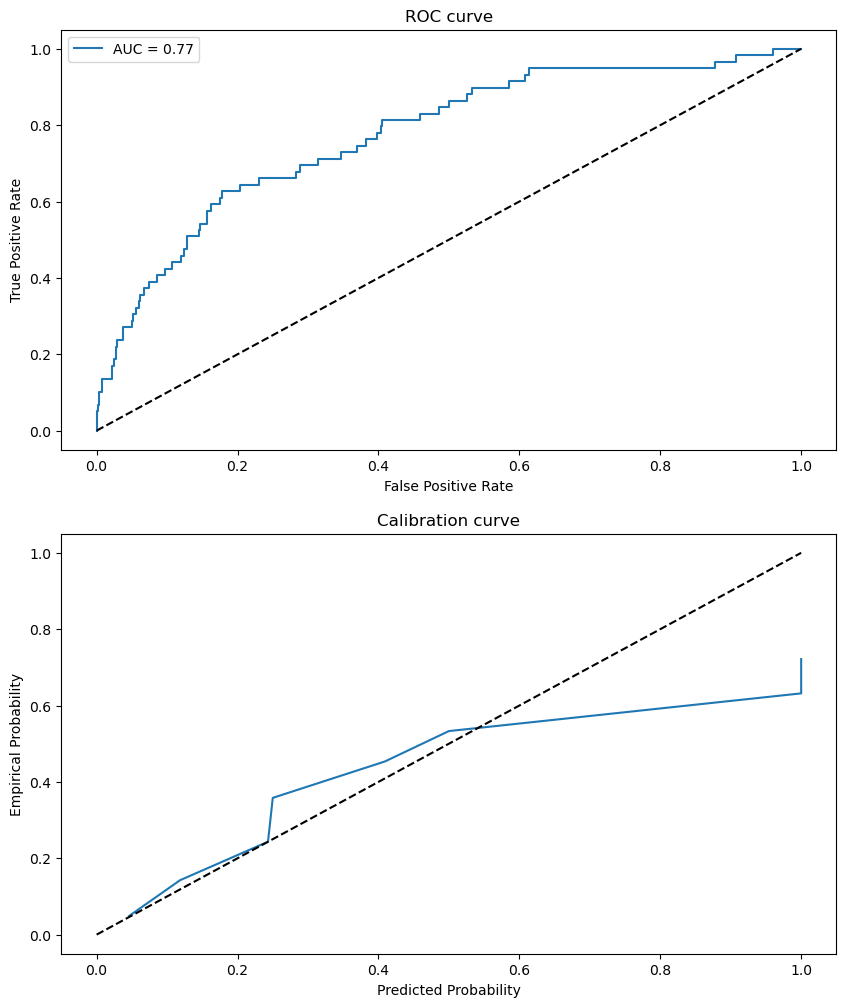

Brier score 0.08019957691431046


In [7]:
#ROC CURVE
from sklearn.metrics import roc_curve, roc_auc_score, brier_score_loss
fig, axs = plt.subplots(2, figsize=(10,12))
y_pred = model.predict(X_cal)
fpr, tpr, _ = roc_curve(y_cal,  y_pred)
auc = roc_auc_score(y_cal, y_pred)
axs[0].plot(fpr,tpr,label= "AUC = " + str(auc)[:4])
axs[0].plot([0, 1], [0, 1], color='black', ls = '--')
axs[0].legend()
axs[0].set_ylabel('True Positive Rate')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_title('ROC curve')

#CALIBRATION CURVE
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_cal, y_pred, n_bins=10)
axs[1].plot(prob_true, prob_pred)
axs[1].plot([0, 1], [0, 1], color='black', ls = '--')
axs[1].set_ylabel('Empirical Probability')
axs[1].set_xlabel('Predicted Probability')
axs[1].set_title("Calibration curve")
plt.show()
#Brier score
print("Brier score", brier_score_loss(y_cal, y_pred))

## Calculando xG Usando Nosso Modelo Durante a UEFA Euro 2020

Com o modelo treinado, podemos agora aplicá-lo a um conjunto de dados de nossa escolha. Escolhemos a UEFA Euro 2020. Primeiro, vamos armazenar os dados da mesma forma que fizemos para a Indian Super League. Em seguida, aplicamos os mesmos pré-processamentos de dados aos dados da Euro 2020. O próximo passo é escalar os dados e fazer as previsões. Por fim, tentaremos identificar os 5 jogadores que acumularam o maior Expected Goals (gols esperados) durante o torneio.


In [8]:
#getting trackings and events for UEFA Euro the same way as we did for Indian Super League
df_match2 = parser.match(competition_id=55, season_id=43)
#get array of match ids
matches2 = df_match2.match_id.unique()
shot_df2 = pd.DataFrame()
track_df2 = pd.DataFrame()
#for each match store shots and trackings in dataframes for the entire season
for match in matches2:
    df_event = parser.event(match)[0]
    df_track = parser.event(match)[2]
    shots = df_event.loc[df_event["type_name"] == "Shot"]
    shots.x = shots.x.apply(lambda cell: cell*105/120)
    shots.y = shots.y.apply(lambda cell: cell*68/80)
    df_track.x = df_track.x.apply(lambda cell: cell*105/120)
    df_track.y = df_track.y.apply(lambda cell: cell*68/80)
    
    shot_df2 = pd.concat([shot_df2, shots], ignore_index = True)
    track_df2 = pd.concat([track_df2, df_track], ignore_index = True)

#reset indicies and remove shots that were not open play or when the goalkeeper was not tracked
shot_df2 = shot_df2.loc[shot_df2["sub_type_name"] == "Open Play"]   
shot_df2.reset_index(drop=True, inplace=True)
track_df2.reset_index(drop=True, inplace=True)
gks_tracked2 = track_df2.loc[track_df2["teammate"] == False].loc[track_df2["position_name"] == "Goalkeeper"]['id'].unique()
shot_df2 = shot_df2.loc[shot_df2["id"].isin(gks_tracked2)]

#DATA WRANGLING. DESCRIPTION OF THESE STEPS CAN BE FOUND IN FEATURE ENGINEERING PART
model_vars2 = shot_df2[["id", "index", "x", "y"]]
model_vars2["goal"] = shot_df2.outcome_name.apply(lambda cell: 1 if cell == "Goal" else 0)
model_vars2["goal_smf"] = model_vars2["goal"].astype(object)
model_vars2['x0'] = model_vars2.x
model_vars2["x"] = model_vars2.x.apply(lambda cell: 105-cell)
model_vars2["c"] = model_vars2.y.apply(lambda cell: abs(34-cell))
model_vars2["angle"] = np.where(np.arctan(7.32 * model_vars2["x"] / (model_vars2["x"]**2 + model_vars2["c"]**2 - (7.32/2)**2)) >= 0, np.arctan(7.32 * model_vars2["x"] /(model_vars2["x"]**2 + model_vars2["c"]**2 - (7.32/2)**2)), np.arctan(7.32 * model_vars2["x"] /(model_vars2["x"]**2 + model_vars2["c"]**2 - (7.32/2)**2)) + np.pi)*180/np.pi
model_vars2["distance"] = np.sqrt(model_vars2["x"]**2 + model_vars2["c"]**2)
model_vars2["xg_basic"]= model_vars2.apply(calculate_xG, b = b, axis=1)
model_vars2["gk_distance"] = shot_df2.apply(dist_to_gk, track_df = track_df2, axis = 1)
model_vars2["gk_distance_y"] = shot_df2.apply(y_to_gk, track_df = track_df2, axis = 1)
model_vars2["triangle"] = shot_df2.apply(players_in_triangle, track_df = track_df2, axis = 1)
model_vars2["close_players"] = shot_df2.apply(three_meters_away, track_df = track_df2, axis = 1)
model_vars2["gk_dist_to_goal"] = shot_df2.apply(gk_dist_to_goal, track_df = track_df2, axis = 1)
model_vars2["is_closer"] = np.where(model_vars2["gk_dist_to_goal"] > model_vars2["distance"], 1, 0)
model_vars2["header"] = shot_df2.body_part_name.apply(lambda cell: 1 if cell == "Head" else 0)

#store data in a matrix
X_unseen = model_vars2[["x0", "is_closer", "angle", "distance", "gk_distance", "gk_distance_y", "triangle", "close_players", "header", "xg_basic"]].values
#scale data
X_unseen = scaler.transform(X_unseen)
#make predictions
xgs_euro = model.predict(X_unseen)
#find out which 5 players had the highest xG
shot_df2["our_xG"] = xgs_euro
shot_df2.groupby(["player_name"])["our_xG"].sum().sort_values(ascending = False)[:5].reset_index()

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,player_name,our_xG
0,Álvaro Borja Morata Martín,2.894736
1,Harry Kane,2.719203
2,Cristiano Ronaldo dos Santos Aveiro,2.480134
3,Kai Havertz,2.356026
4,Gerard Moreno Balaguero,2.349644
